# 01 — Exploratory Data Analysis
## Hockey Expected Goals Model | MoneyPuck 2022–2025

This notebook explores three seasons of NHL shot data before any modelling. The goal is to understand the data structurally, identify what MoneyPuck's published `xGoal` gets right and wrong, and decide which features are worth engineering.

**Sections**
1. Setup
2. Load data
3. Data quality
4. Coordinate system
5. Shot locations — goals vs. no-goals
6. Game context
7. Zone analysis
8. Shot type analysis
9. Distance and angle
10. MoneyPuck calibration audit
11. Jets vs. league
12. EDA summary
13. Save handoff file

**Data split reminder**
- Train: 2014-15 to 2023-24
- Validate: 2024-25

---
## 1. Setup

In [1]:
# Uncomment and run once if packages are missing
# %pip install pandas numpy matplotlib seaborn scipy pyarrow fastparquet lightgbm shap

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import gaussian_kde
from matplotlib.colors import LinearSegmentedColormap
import warnings
import os

warnings.filterwarnings('ignore')

# Paths
DATA_DIR    = '../data/'
FIGURES_DIR = '../outputs/figures/'
os.makedirs(FIGURES_DIR, exist_ok=True)

# Rink constants — MoneyPuck adjusted coordinate system
# All shots attack left-to-right; net at x=89, blue line at x=25
NET_X, NET_Y = 89, 0
BLUE_LINE_X  = 25
X_MIN, X_MAX = 15, 102
Y_MIN, Y_MAX = -43, 43

# Coordinate columns used throughout
X_COL = 'xCordAdjusted'
Y_COL = 'yCordAdjusted'

# Colours
GOAL_COLOR      = '#e63946'
NOGOAL_COLOR    = '#457b9d'
ACCENT          = '#f4a261'
MONEYPUCK_COLOR = '#9b5de5'

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#0f1117',
    'axes.edgecolor':   '#333344',
    'axes.labelcolor':  '#ccccdd',
    'xtick.color':      '#ccccdd',
    'ytick.color':      '#ccccdd',
    'text.color':       '#ccccdd',
    'grid.color':       '#1e1e2e',
    'grid.linewidth':   0.6,
    'font.family':      'monospace',
    'figure.dpi':       130,
})

print('Setup complete.')

Setup complete.


In [3]:
def draw_offensive_zone(ax):
    """Draw an offensive zone outline on a matplotlib axis."""
    ax.plot([X_MIN, X_MIN, 89, 100, 100, 89, X_MIN],
            [-42.5, 42.5, 42.5, 22, -22, -42.5, -42.5],
            color='#334455', lw=1.5, zorder=2)
    crease = mpatches.Arc((NET_X, NET_Y), width=8, height=8, angle=0,
                           theta1=90, theta2=270, color='#446688', lw=1.5, zorder=3)
    ax.add_patch(crease)
    ax.plot([NET_X, NET_X], [-3, 3], color='#cc3333', lw=2, zorder=3)
    ax.axvline(BLUE_LINE_X, color='#3366aa', lw=0.8, alpha=0.3, zorder=2)
    ax.scatter([NET_X], [NET_Y], color='#cc3333', s=80, zorder=5, marker='D')
    for y in [-22, 22]:
        ax.scatter([69], [y], color='#cc3333', s=30, zorder=4, alpha=0.7)
    ax.set_xlim(X_MIN, X_MAX)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.set_aspect('equal')
    ax.axis('off')

print('draw_offensive_zone() ready.')

draw_offensive_zone() ready.


---
## 2. Load Data

In [4]:
files = {
    '2014': f'{DATA_DIR}shots_2014.csv',
    '2015': f'{DATA_DIR}shots_2015.csv',
    '2016': f'{DATA_DIR}shots_2016.csv',
    '2017': f'{DATA_DIR}shots_2017.csv',
    '2018': f'{DATA_DIR}shots_2018.csv',
    '2019': f'{DATA_DIR}shots_2019.csv',
    '2020': f'{DATA_DIR}shots_2020.csv',
    '2021': f'{DATA_DIR}shots_2021.csv',
    '2022': f'{DATA_DIR}shots_2022.csv',
    '2023': f'{DATA_DIR}shots_2023.csv',
    '2024': f'{DATA_DIR}shots_2024.csv',
    # '2025': f'{DATA_DIR}shots_2025.csv'  # TEST SET — locked until notebook 04
}

dfs = []
for season, path in files.items():
    df = pd.read_csv(path, low_memory=False)
    print(f'Season {season}: {len(df):,} rows')
    dfs.append(df)

# season column already present in MoneyPuck CSVs
raw = pd.concat(dfs, ignore_index=True)
print(f'\nTotal: {len(raw):,} rows, {raw.shape[1]} columns')

Season 2014: 109,627 rows
Season 2015: 109,461 rows
Season 2016: 110,953 rows
Season 2017: 119,715 rows
Season 2018: 117,622 rows
Season 2019: 104,172 rows
Season 2020: 78,611 rows
Season 2021: 121,471 rows
Season 2022: 122,026 rows
Season 2023: 122,472 rows
Season 2024: 119,870 rows

Total: 1,236,000 rows, 137 columns


---
## 3. Data Quality

Select core columns, check nulls, and make cleaning decisions before any analysis.

In [5]:
CORE_COLS = [
    'xCordAdjusted', 'yCordAdjusted',
    'xCord', 'yCord',
    'goal',                  # binary target — confirmed column name in MoneyPuck data
    'xGoal',                 # MoneyPuck xG benchmark
    'shotType',
    'shotDistance',
    'shotAngle',
    'shooterName',
    'shooterLeftRight',
    'teamCode',
    'season',
    'game_id',
    'time',
    'period',
    'isPlayoffGame',
    'isHomeTeam',
    'shotRebound',
    'shotRush',
    'offWing',
    'homeSkatersOnIce',
    'awaySkatersOnIce',
]

raw = raw[[c for c in CORE_COLS if c in raw.columns]].copy()
print(f'Shape: {raw.shape}')

Shape: (1236000, 23)


In [6]:
null_summary = raw.isnull().sum()
null_summary = null_summary[null_summary > 0].sort_values(ascending=False)
print('Columns with nulls:')
print(null_summary.to_string())
print(f'\nRows with any null: {raw.isnull().any(axis=1).sum():,}')

Columns with nulls:
shooterLeftRight    6312
shotType            3193
shooterName          105

Rows with any null: 9,416


In [7]:
# Null handling decisions:
#
# shotType (3,015 nulls):
#   Goal rate in null rows = 15% vs 7% overall — these are real shots.
#   Dropping them removes 453 real goals. Fill with 'Unknown' instead.
#
# shooterLeftRight (6,226 nulls):
#   Fill with 'U' as its own category.
#
# shooterName (19 nulls):
#   Negligible, not a model feature. Leave as-is.

raw['shotType']         = raw['shotType'].fillna('Unknown')
raw['shooterLeftRight'] = raw['shooterLeftRight'].fillna('U')

print(f'Total rows: {len(raw):,}')
print(f'Remaining nulls: {raw.isnull().sum().sum()}')
print(f'\nGoal rate: {raw["goal"].mean():.3f} ({raw["goal"].mean()*100:.1f}%)')
print(f'Goals    : {raw["goal"].sum():,}')
print(f'Non-goals: {(raw["goal"]==0).sum():,}')
print()
print('Shot type distribution:')
print(raw['shotType'].value_counts().to_string())

Total rows: 1,236,000
Remaining nulls: 105

Goal rate: 0.068 (6.8%)
Goals    : 84,206
Non-goals: 1,151,794

Shot type distribution:
shotType
WRIST      644345
SLAP       190800
SNAP       180857
BACK        91235
TIP         88004
DEFL        26766
WRAP        10800
Unknown      3193


---
## 4. Coordinate System

`xCordAdjusted` / `yCordAdjusted` flip all shots to attack in the same direction, correcting for arena-specific camera positioning differences. We use these throughout.

- x: 0 to 100, net at x = 89, blue line at x = 25
- y: -42.5 to +42.5, centre at y = 0
- Offensive zone: x > 25

In [8]:
print(f'x range: {raw[X_COL].min():.1f} to {raw[X_COL].max():.1f}')
print(f'y range: {raw[Y_COL].min():.1f} to {raw[Y_COL].max():.1f}')

oz = raw[raw[X_COL] > 25].copy()
print(f'\nOffensive zone shots: {len(oz):,} ({len(oz)/len(raw)*100:.1f}% of total)')

x range: 0.0 to 100.0
y range: -43.0 to 43.0

Offensive zone shots: 1,200,510 (97.1% of total)


---
## 5. Shot Locations — Goals vs. No-Goals

Scatter plot shows the raw picture. KDE map reveals the density structure. Both are on the full dataset (all game contexts) since we are looking at spatial patterns, not rates.

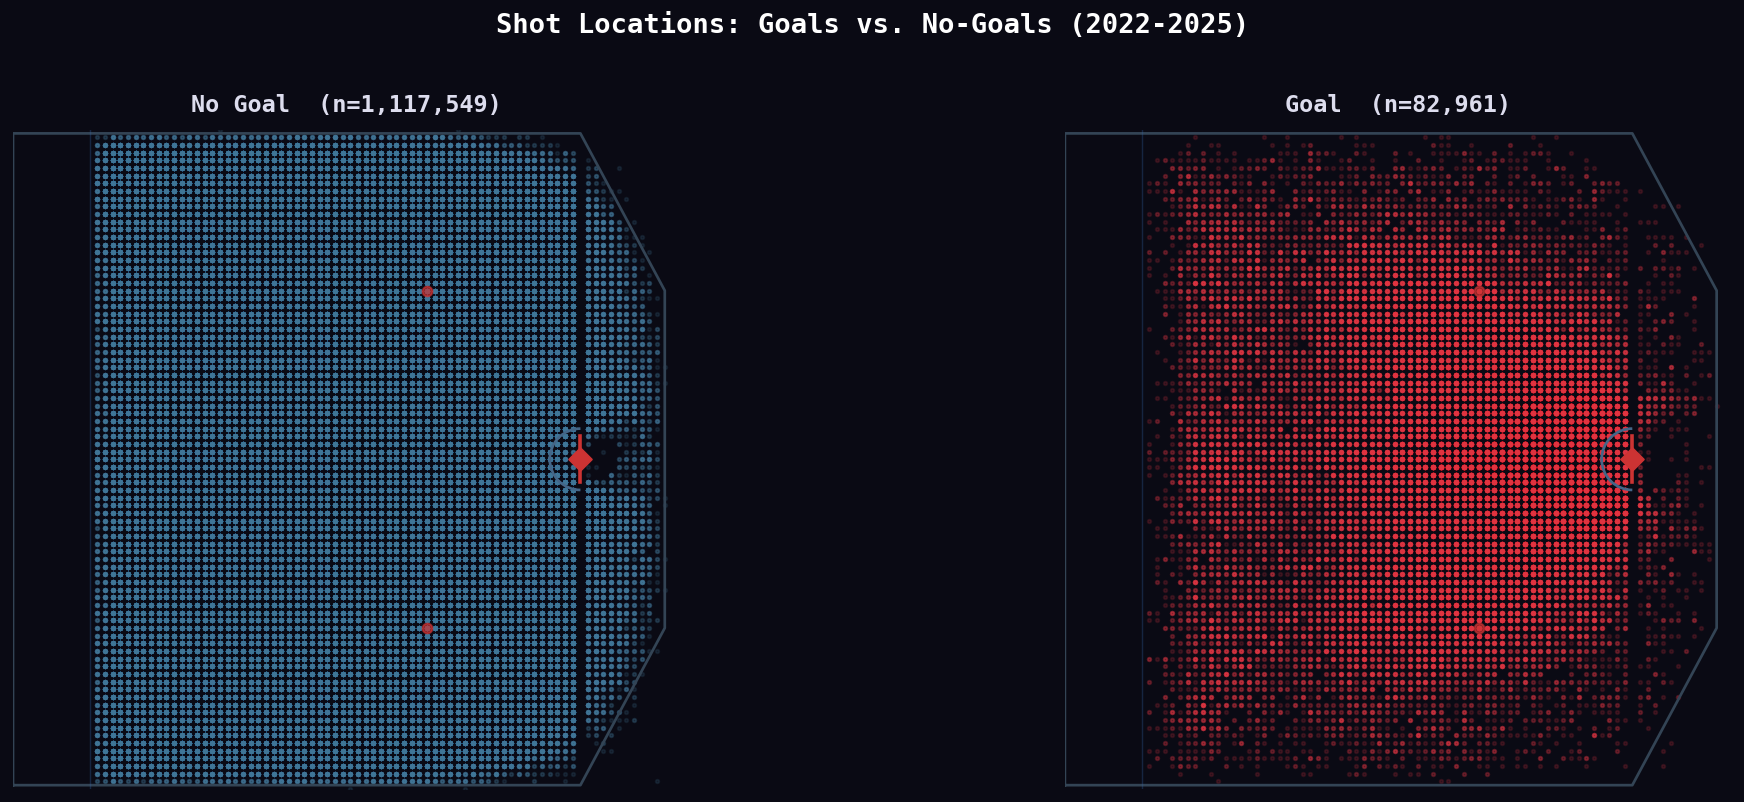

In [9]:
goals   = oz[oz['goal'] == 1]
nogoals = oz[oz['goal'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('#0a0a14')

for ax, subset, label, color in zip(
    axes,
    [nogoals, goals],
    ['No Goal', 'Goal'],
    [NOGOAL_COLOR, GOAL_COLOR]
):
    draw_offensive_zone(ax)
    ax.scatter(subset[X_COL], subset[Y_COL],
               s=4, alpha=0.15, color=color, rasterized=True)
    ax.set_title(f'{label}  (n={len(subset):,})', color='#ddddee',
                 fontsize=13, pad=10, fontweight='bold')

fig.suptitle('Shot Locations: Goals vs. No-Goals (2022-2025)',
             color='white', fontsize=15, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}01_shot_scatter.png', bbox_inches='tight',
            facecolor='#0a0a14', dpi=150)
plt.show()

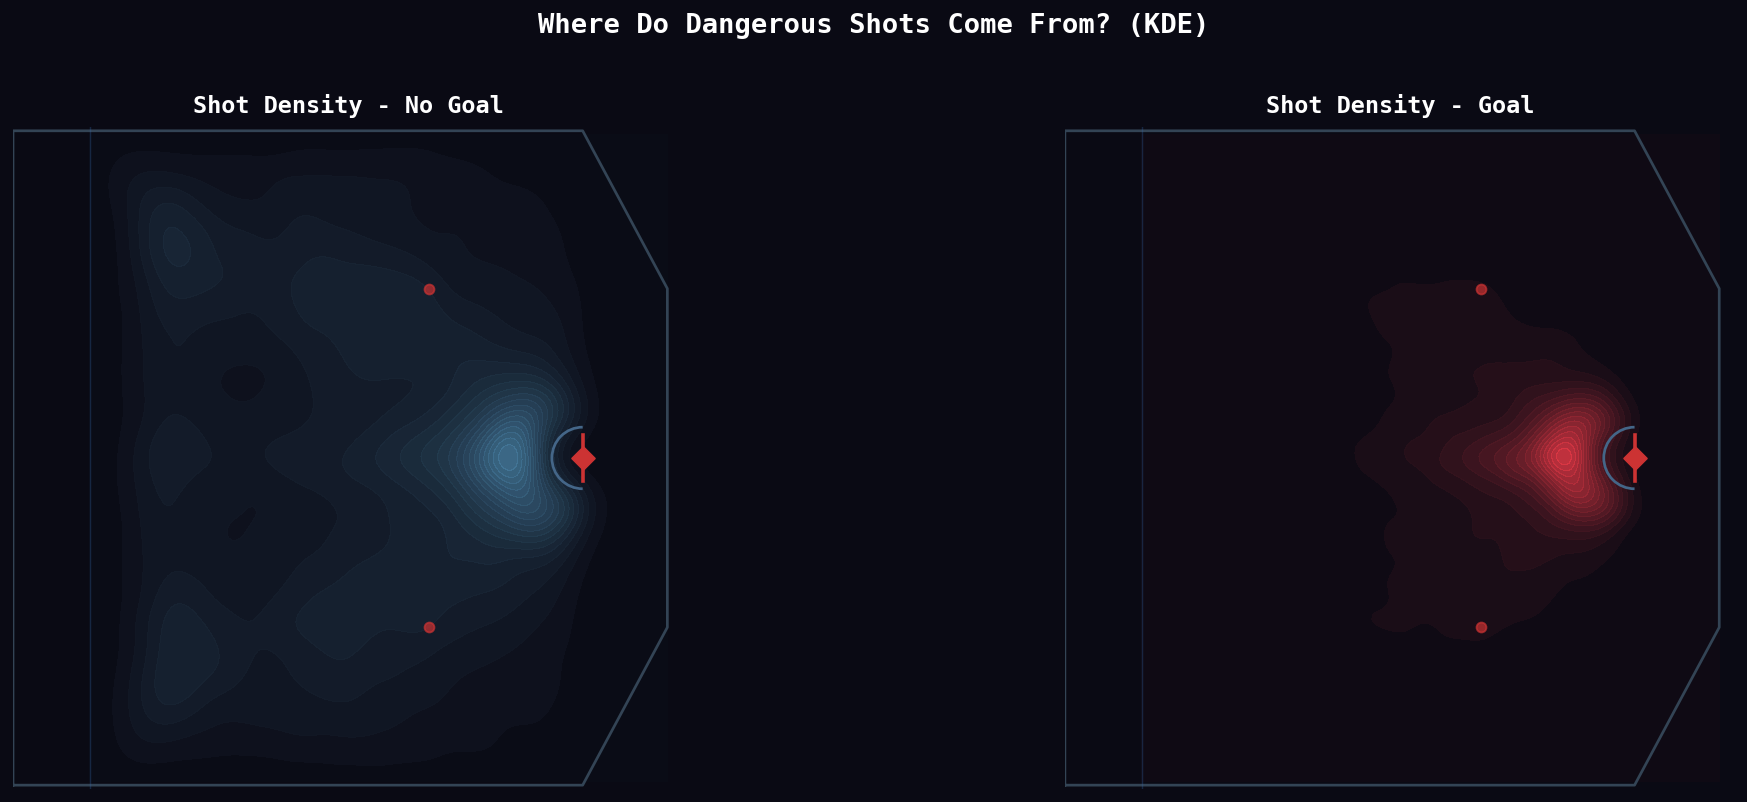

In [10]:
def kde_heatmap(ax, x, y, color, title, n_sample=25000):
    """2D kernel density heatmap overlaid on the offensive zone."""
    idx = np.random.choice(len(x), size=min(n_sample, len(x)), replace=False)
    xs, ys = x.iloc[idx].values, y.iloc[idx].values
    xi = np.linspace(25, 100, 200)
    yi = np.linspace(-42, 42, 200)
    Xi, Yi = np.meshgrid(xi, yi)
    kde = gaussian_kde(np.vstack([xs, ys]), bw_method=0.12)
    Zi = kde(np.vstack([Xi.ravel(), Yi.ravel()])).reshape(Xi.shape)
    cmap = LinearSegmentedColormap.from_list('rink', ['#0a0a14', color], N=256)
    ax.contourf(Xi, Yi, Zi, levels=20, cmap=cmap, alpha=0.85, zorder=1)
    draw_offensive_zone(ax)
    ax.set_title(title, color='white', fontsize=13, pad=8, fontweight='bold')


fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('#0a0a14')

kde_heatmap(axes[0], nogoals[X_COL], nogoals[Y_COL],
            NOGOAL_COLOR, 'Shot Density - No Goal', n_sample=50000)
kde_heatmap(axes[1], goals[X_COL],   goals[Y_COL],
            GOAL_COLOR,   'Shot Density - Goal',    n_sample=25000)

fig.suptitle('Where Do Dangerous Shots Come From? (KDE)',
             color='white', fontsize=15, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}02_kde_density.png', bbox_inches='tight',
            facecolor='#0a0a14', dpi=150)
plt.show()

# Goals collapse to a tight cluster in front of the net.
# No-goals spread across the entire zone.
# Location is the dominant signal — confirmed visually before any modelling.

---
## 6. Game Context

The dataset spans four distinct game states with meaningfully different goal rates. We create a `game_context` column to use as a feature and establish a regulation-only subset for zone and shot type analysis.

In [11]:
oz['game_context'] = 'regulation'
oz.loc[(oz['isPlayoffGame'] == 0) & (oz['period'] == 4), 'game_context'] = 'reg_ot_3v3'
oz.loc[(oz['isPlayoffGame'] == 1) & (oz['period'] <= 3), 'game_context'] = 'playoff_reg'
oz.loc[(oz['isPlayoffGame'] == 1) & (oz['period'] >  3), 'game_context'] = 'playoff_ot'

ctx = oz.groupby('game_context').agg(
    shots=('goal', 'count'),
    goal_rate=('goal', 'mean'),
    mean_xg=('xGoal', 'mean')
).round(4)
ctx['mp_residual'] = (ctx['goal_rate'] - ctx['mean_xg']).round(4)
print(ctx.to_string())



                shots  goal_rate  mean_xg  mp_residual
game_context                                          
playoff_ot       3859     0.0575   0.0568       0.0007
playoff_reg     81403     0.0659   0.0701      -0.0042
reg_ot_3v3      16364     0.1171   0.0882       0.0289
regulation    1098884     0.0687   0.0690      -0.0003


Key finding:
- reg_ot_3v3: 13.8% goal rate vs 7.0% regulation (+6.8pp)
- MoneyPuck underestimates 3v3 OT by 4.4pp — most miscalibrated game state
- Explanation: 3-on-3 creates open ice; shots look geometrically similar to regulation but convert at nearly double the rate

In [12]:
# Regulation-only subset for zone and shot type analysis
# Avoids 3v3 OT inflating conversion rates
oz_reg = oz[oz['game_context'] == 'regulation'].copy()
print(f'Regulation shots: {len(oz_reg):,} ({len(oz_reg)/len(oz)*100:.1f}% of oz)')

Regulation shots: 1,098,884 (91.5% of oz)


---
## 7. Zone Analysis

The offensive zone divided into five regions. Regulation shots only.

In [13]:
# Vectorized zone assignment — avoids slow row-wise apply()
x = oz[X_COL]
y = oz[Y_COL].abs()

conditions = [
    (x >= 69) & (y <= 22),
    (x >= 69) & (y >  22),
    (x >= 54) & (y <= 15),
    (x >= 54) & (y >  15),
]
oz['zone'] = np.select(conditions, ['Slot', 'Corner', 'High Slot', 'Circle'],
                        default='Point')


oz_reg = oz[oz['game_context'] == 'regulation'].copy()

zone_stats = oz_reg.groupby('zone').agg(
    shots=('goal', 'count'),
    goals=('goal', 'sum'),
    mean_xg=('xGoal', 'mean')
).assign(
    shooting_pct=lambda d: d['goals'] / d['shots'],
    pct_of_shots=lambda d: d['shots'] / d['shots'].sum()
).sort_values('shooting_pct', ascending=False)

print(zone_stats.round(4).to_string())

            shots  goals  mean_xg  shooting_pct  pct_of_shots
zone                                                         
Slot       396468  46915   0.1246        0.1183        0.3608
High Slot  123598  10844   0.0808        0.0877        0.1125
Circle     156985   6748   0.0363        0.0430        0.1429
Point      355733   9251   0.0256        0.0260        0.3237
Corner      66100   1702   0.0247        0.0257        0.0602


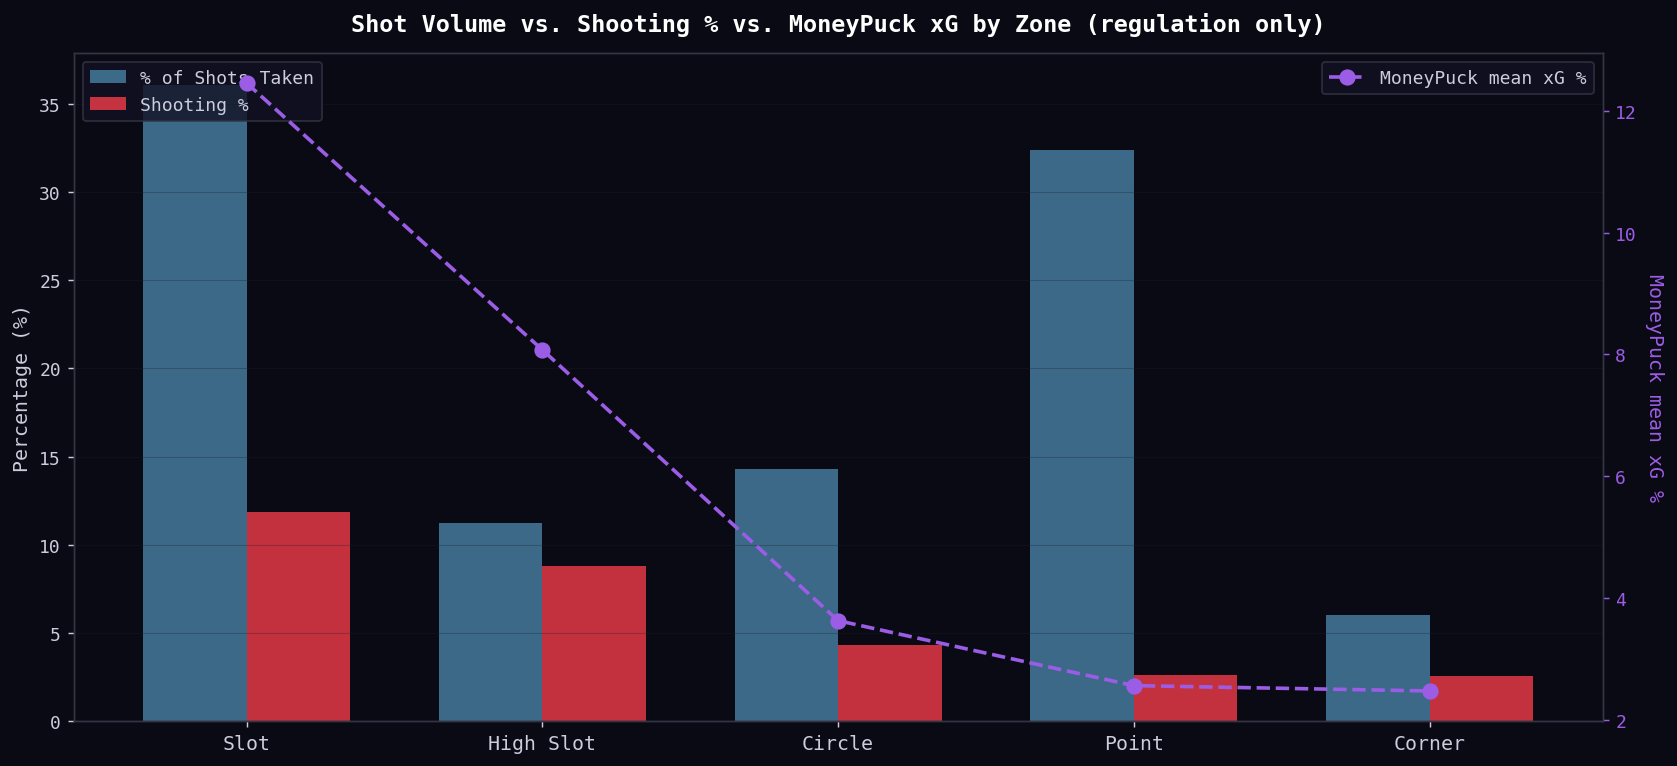

In [14]:
zones = zone_stats.index.tolist()
x_pos = np.arange(len(zones))
width = 0.35

fig, ax1 = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#0a0a14')
ax1.set_facecolor('#0a0a14')

ax1.bar(x_pos - width/2, zone_stats['pct_of_shots'] * 100, width,
        label='% of Shots Taken', color=NOGOAL_COLOR, alpha=0.85)
ax1.bar(x_pos + width/2, zone_stats['shooting_pct'] * 100, width,
        label='Shooting %', color=GOAL_COLOR, alpha=0.85)

ax2 = ax1.twinx()
ax2.plot(x_pos, zone_stats['mean_xg'] * 100, 'o--',
         color=MONEYPUCK_COLOR, lw=2, ms=8, label='MoneyPuck mean xG %')
ax2.set_ylabel('MoneyPuck mean xG %', color=MONEYPUCK_COLOR, fontsize=11,
               rotation=270, labelpad=15)
ax2.tick_params(colors=MONEYPUCK_COLOR)
ax2.legend(loc='upper right', facecolor='#111122', edgecolor='#333344')

ax1.set_xticks(x_pos)
ax1.set_xticklabels(zones, fontsize=11)
ax1.set_ylabel('Percentage (%)', fontsize=11)
ax1.set_title('Shot Volume vs. Shooting % vs. MoneyPuck xG by Zone (regulation only)',
              color='white', fontsize=13, pad=12, fontweight='bold')
ax1.legend(loc='upper left', facecolor='#111122', edgecolor='#333344')
ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}03_zone_analysis.png', bbox_inches='tight',
            facecolor='#0a0a14', dpi=150)
plt.show()

# Key finding:
# Point = 29.6% of shots, 2.7% conversion — worst zone, most attempted
# Slot  = 38.2% of shots, 11.7% conversion — 4x better conversion than Point
# MoneyPuck xG tracks zone-level shooting % closely — miscalibration is at
# a finer grain (shot type within zone) rather than zone level

---
## 8. Shot Type Analysis

Shot type carries predictive signal independent of location. Regulation shots only; `Unknown` excluded from the chart (present in the model as its own category).

In [15]:
shot_type_stats = (
    oz_reg[oz_reg['shotType'] != 'Unknown']
    .groupby('shotType')
    .agg(shots=('goal', 'count'), shooting_pct=('goal', 'mean'))
    .sort_values('shots', ascending=False)
)
print(shot_type_stats.round(4).to_string())

           shots  shooting_pct
shotType                      
WRIST     568947        0.0657
SLAP      170141        0.0448
SNAP      163607        0.0784
BACK       80793        0.0853
TIP        78873        0.0953
DEFL       23925        0.0951
WRAP        9788        0.0534


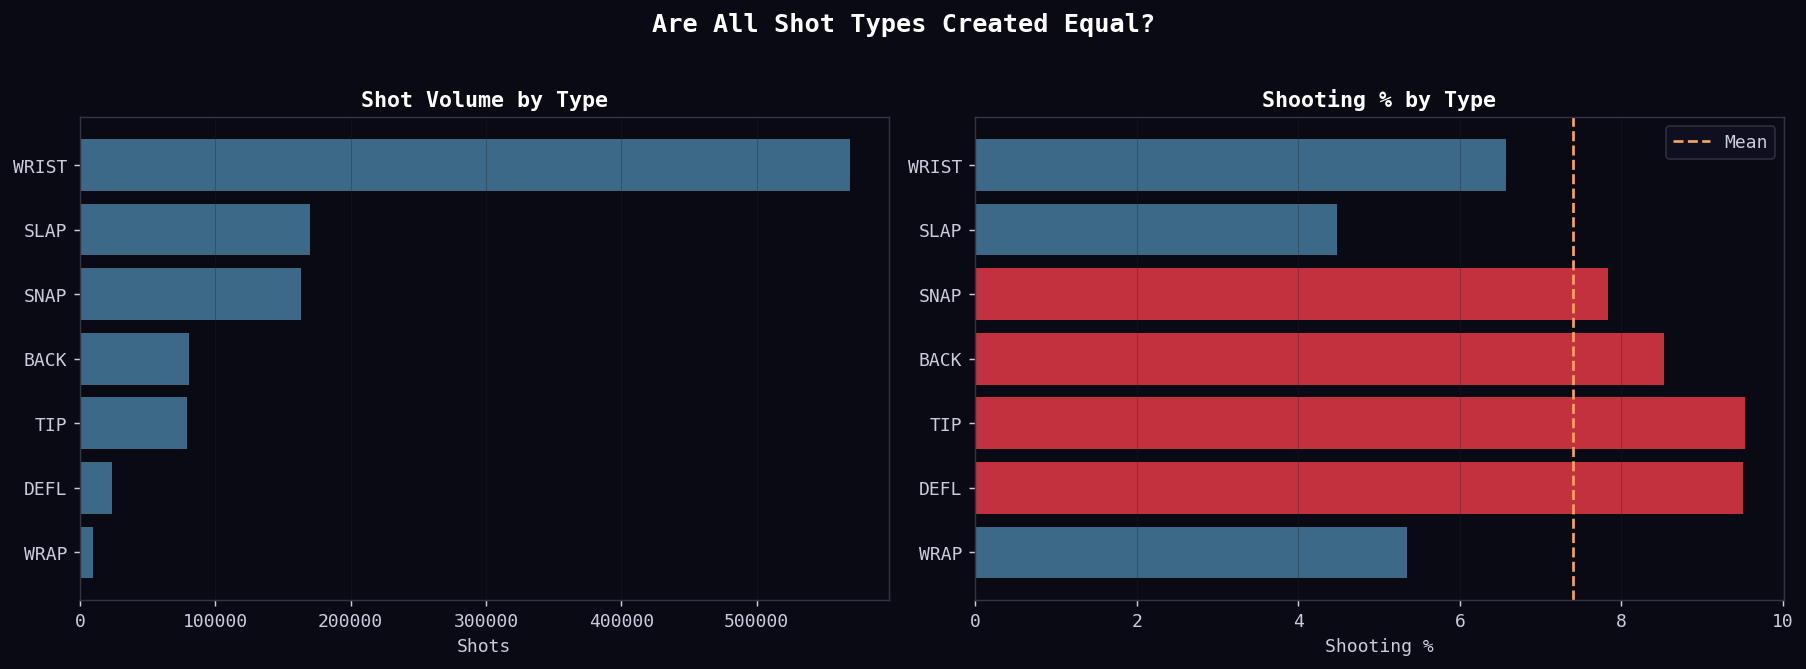

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0a0a14')
for ax in axes:
    ax.set_facecolor('#0a0a14')

axes[0].barh(shot_type_stats.index, shot_type_stats['shots'],
             color=NOGOAL_COLOR, alpha=0.85)
axes[0].set_title('Shot Volume by Type', color='white', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Shots')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

mean_pct   = shot_type_stats['shooting_pct'].mean()
bar_colors = [GOAL_COLOR if s > mean_pct else NOGOAL_COLOR
              for s in shot_type_stats['shooting_pct']]
axes[1].barh(shot_type_stats.index, shot_type_stats['shooting_pct'] * 100,
             color=bar_colors, alpha=0.85)
axes[1].axvline(mean_pct * 100, color=ACCENT, lw=1.5, linestyle='--', label='Mean')
axes[1].set_title('Shooting % by Type', color='white', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Shooting %')
axes[1].invert_yaxis()
axes[1].legend(facecolor='#111122', edgecolor='#333344')
axes[1].grid(axis='x', alpha=0.3)

fig.suptitle('Are All Shot Types Created Equal?',
             color='white', fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}04_shot_type.png', bbox_inches='tight',
            facecolor='#0a0a14', dpi=150)
plt.show()



Key finding:
- SLAP = lowest conversion (4.9%) despite perceived danger
- DEFL = highest conversion (9.3%) but only 1.9% of shots — underutilised
- WRIST = most common (52%), close to average — natural baseline shot type

---
## 9. Distance and Angle

The two core spatial features. We check their individual predictive signal to understand how to engineer them — specifically whether they need interaction terms or can work independently.

In [17]:
# MoneyPuck pre-computes both — derive from coordinates only if missing
if 'shotDistance' not in oz.columns:
    oz['shotDistance'] = np.sqrt(
        (oz[X_COL] - NET_X)**2 + (oz[Y_COL] - NET_Y)**2
    )
if 'shotAngle' not in oz.columns:
    oz['shotAngle'] = np.abs(np.degrees(
        np.arctan2(oz[Y_COL] - NET_Y, oz[X_COL] - NET_X)
    ))

oz['dist_bin']  = pd.cut(oz['shotDistance'], bins=range(0, 110, 5))
oz['angle_bin'] = pd.cut(oz['shotAngle'],    bins=range(0,  95, 5))

dist_stats  = oz.groupby('dist_bin').agg(
    shots=('goal', 'count'), goal_rate=('goal', 'mean')).dropna()
angle_stats = oz.groupby('angle_bin').agg(
    shots=('goal', 'count'), goal_rate=('goal', 'mean')).dropna()

print(f'Distance range : {oz["shotDistance"].min():.1f} to {oz["shotDistance"].max():.1f} ft')
print(f'Angle range    : {oz["shotAngle"].min():.1f} to {oz["shotAngle"].max():.1f} degrees')

Distance range : 1.0 to 75.7 ft
Angle range    : -88.6 to 88.6 degrees


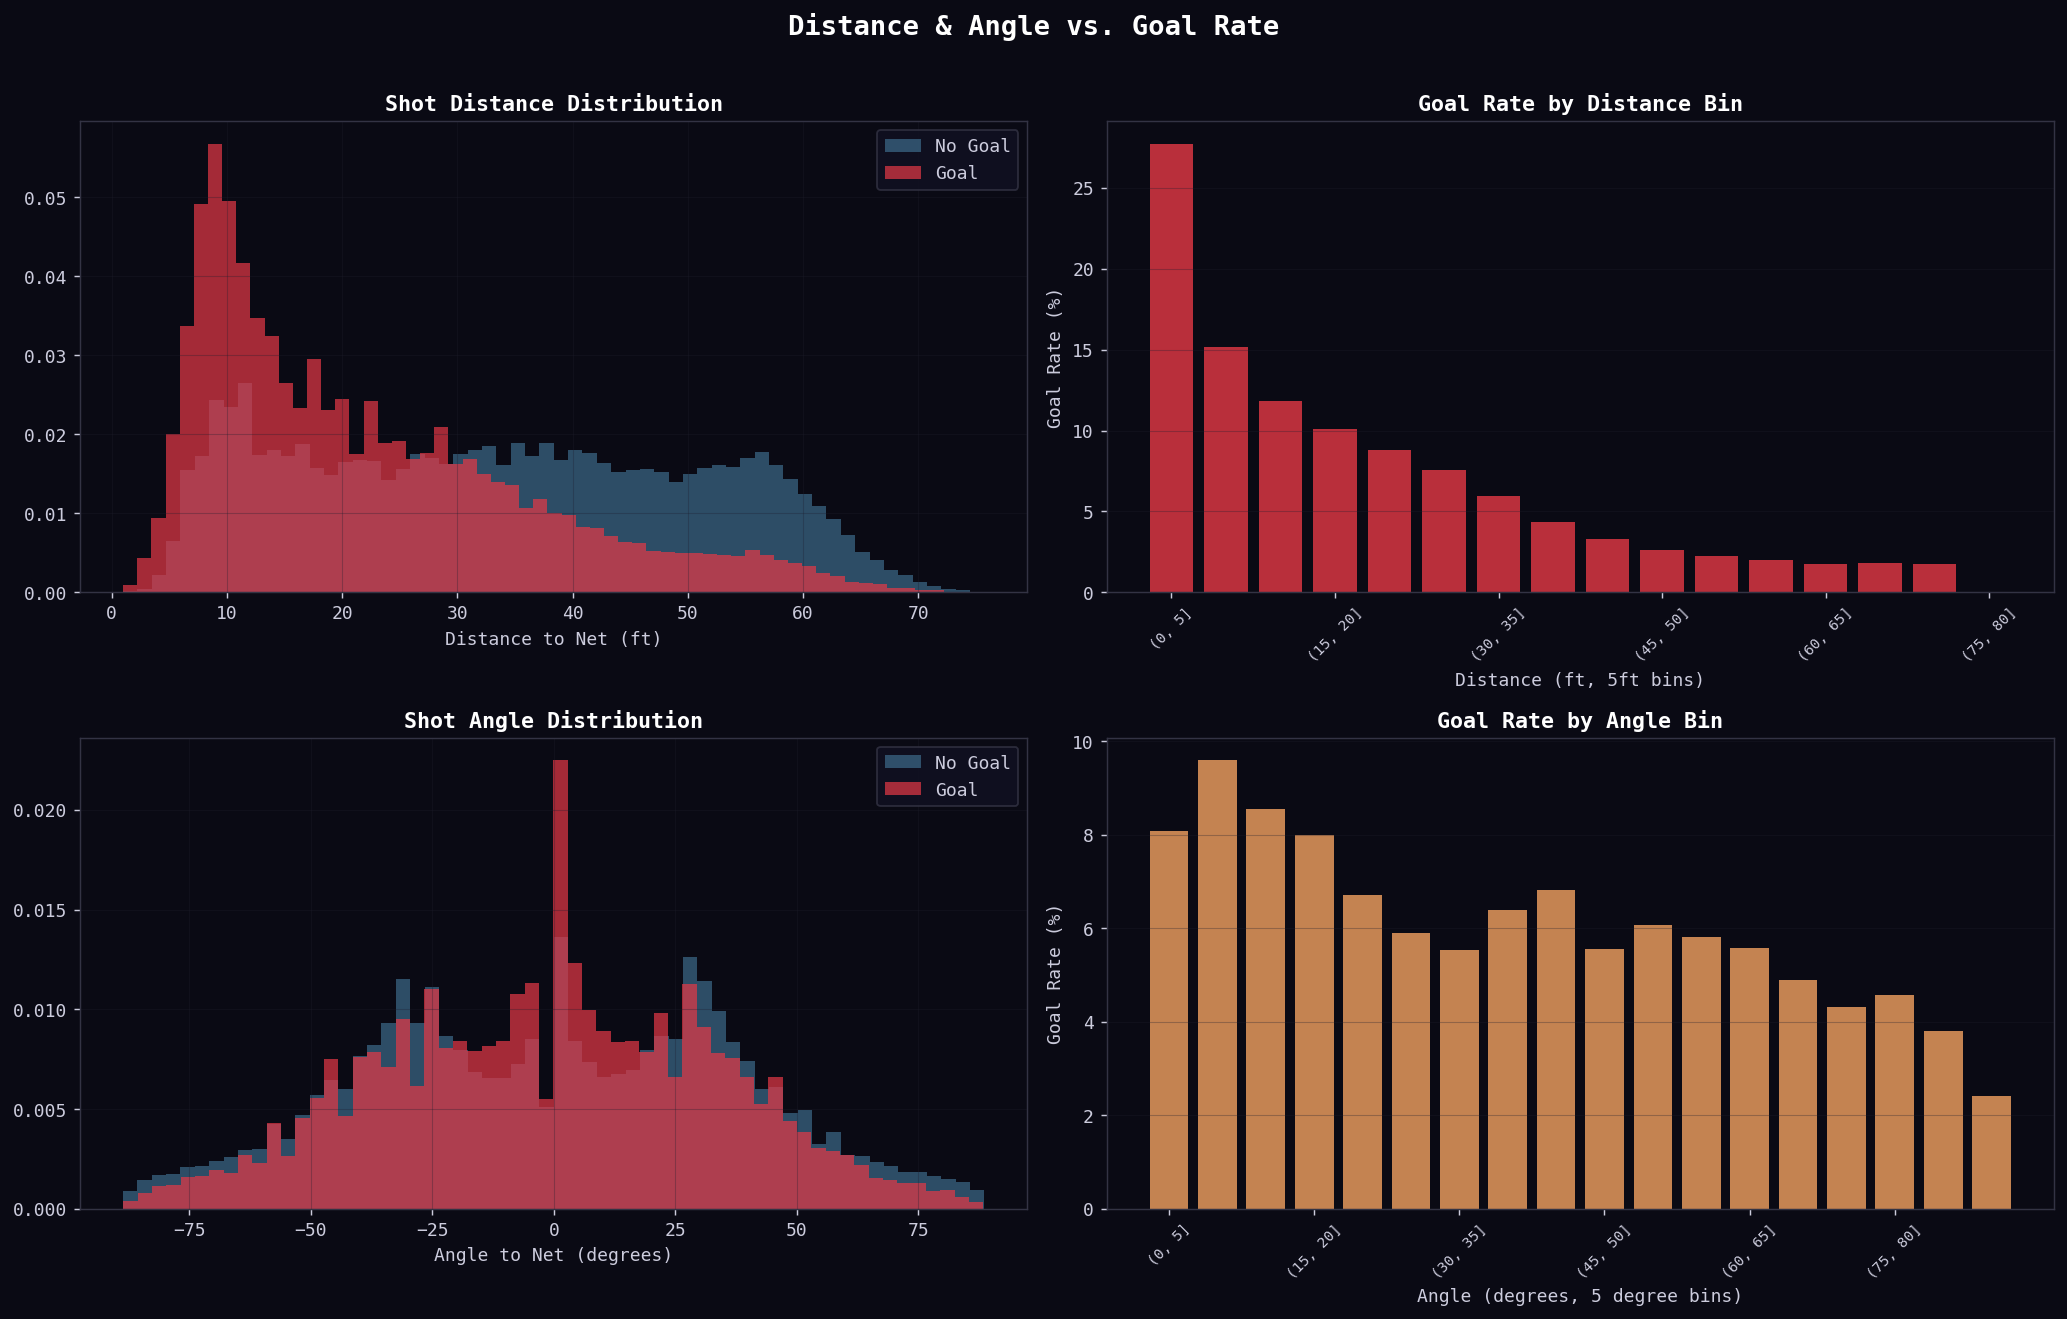

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('#0a0a14')
for ax in axes.flat:
    ax.set_facecolor('#0a0a14')

# Distance distribution
axes[0,0].hist(oz[oz['goal']==0]['shotDistance'], bins=60,
               color=NOGOAL_COLOR, alpha=0.6, density=True, label='No Goal')
axes[0,0].hist(oz[oz['goal']==1]['shotDistance'], bins=60,
               color=GOAL_COLOR,   alpha=0.7, density=True, label='Goal')
axes[0,0].set_title('Shot Distance Distribution', color='white', fontweight='bold')
axes[0,0].set_xlabel('Distance to Net (ft)')
axes[0,0].legend(facecolor='#111122', edgecolor='#333344')
axes[0,0].grid(alpha=0.3)

# Goal rate by distance
x_labels = [str(b) for b in dist_stats.index]
axes[0,1].bar(range(len(dist_stats)), dist_stats['goal_rate'] * 100,
              color=GOAL_COLOR, alpha=0.8)
axes[0,1].set_title('Goal Rate by Distance Bin', color='white', fontweight='bold')
axes[0,1].set_ylabel('Goal Rate (%)')
axes[0,1].set_xlabel('Distance (ft, 5ft bins)')
axes[0,1].set_xticks(range(0, len(dist_stats), 3))
axes[0,1].set_xticklabels(x_labels[::3], rotation=45, fontsize=8)
axes[0,1].grid(axis='y', alpha=0.3)

# Angle distribution
axes[1,0].hist(oz[oz['goal']==0]['shotAngle'], bins=60,
               color=NOGOAL_COLOR, alpha=0.6, density=True, label='No Goal')
axes[1,0].hist(oz[oz['goal']==1]['shotAngle'], bins=60,
               color=GOAL_COLOR,   alpha=0.7, density=True, label='Goal')
axes[1,0].set_title('Shot Angle Distribution', color='white', fontweight='bold')
axes[1,0].set_xlabel('Angle to Net (degrees)')
axes[1,0].legend(facecolor='#111122', edgecolor='#333344')
axes[1,0].grid(alpha=0.3)

# Goal rate by angle
a_labels = [str(b) for b in angle_stats.index]
axes[1,1].bar(range(len(angle_stats)), angle_stats['goal_rate'] * 100,
              color=ACCENT, alpha=0.8)
axes[1,1].set_title('Goal Rate by Angle Bin', color='white', fontweight='bold')
axes[1,1].set_ylabel('Goal Rate (%)')
axes[1,1].set_xlabel('Angle (degrees, 5 degree bins)')
axes[1,1].set_xticks(range(0, len(angle_stats), 3))
axes[1,1].set_xticklabels(a_labels[::3], rotation=45, fontsize=8)
axes[1,1].grid(axis='y', alpha=0.3)

fig.suptitle('Distance & Angle vs. Goal Rate',
             color='white', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}05_distance_angle.png', bbox_inches='tight',
            facecolor='#0a0a14', dpi=150)
plt.show()



Key finding:

Distance: strong non-linear signal — ~26% at 0-5ft, ~2% beyond 40ft

Angle: weak standalone signal — goal rate stays ~7-9% across 0-70 degrees
- 0 degree shots at 27ft mean distance convert at 10.7% it is the clear lane, not the angle itself. Angle must be paired with distance.
 

---
## 10. MoneyPuck Calibration Audit

A perfectly calibrated model means shots rated at 0.10 xG actually score 10% of the time. We plot predicted vs. actual, then drill into where MoneyPuck fails.

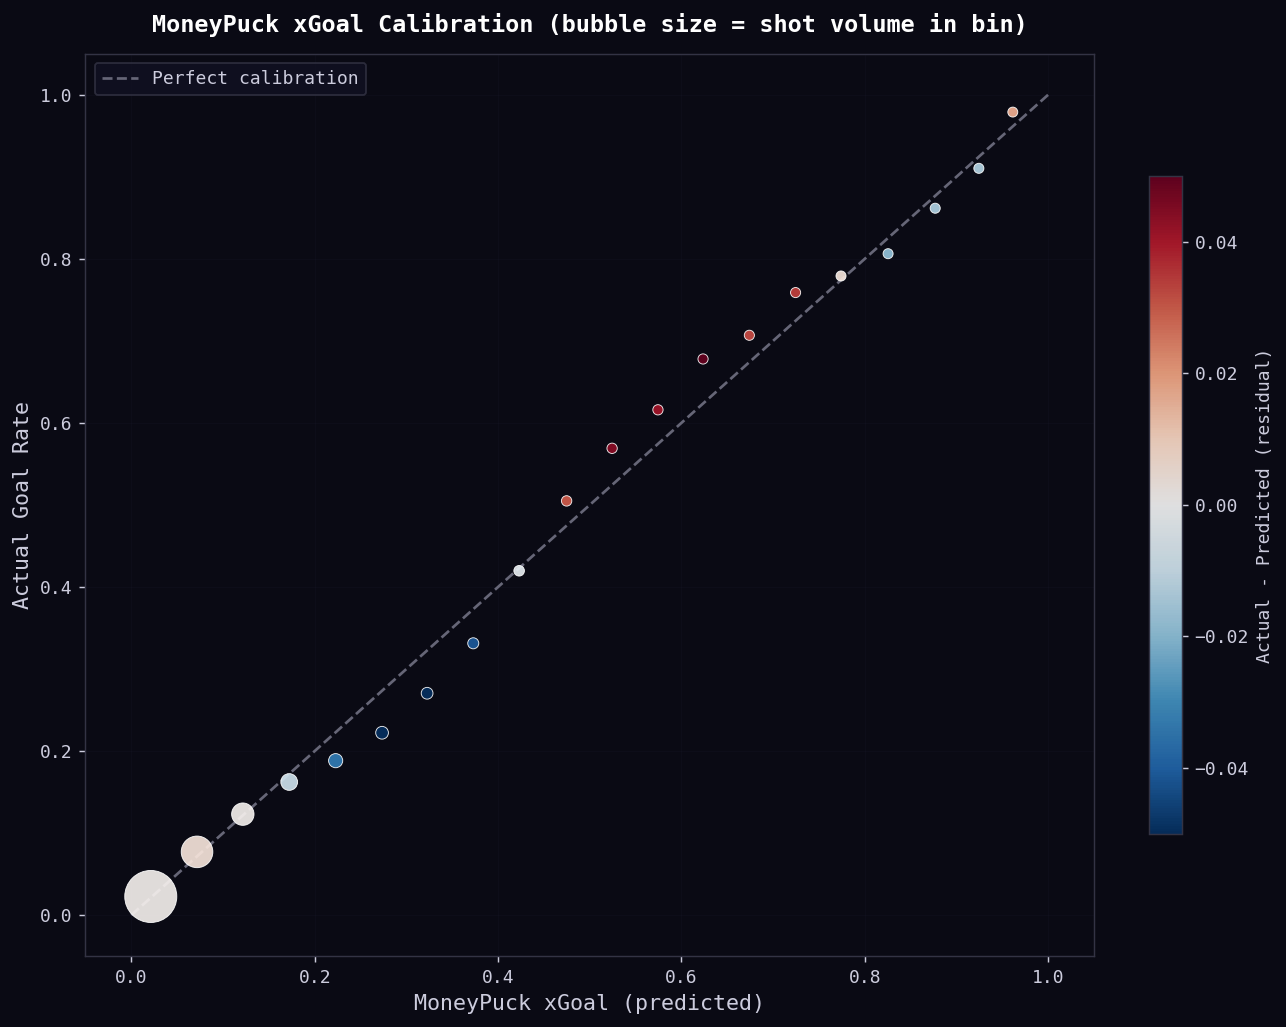

Largest divergences (|residual| > 0.02):
             shots  actual_rate  mean_xg  residual
xg_bin                                            
(0.6, 0.65]   1577       0.6779   0.6235    0.0543
(0.3, 0.35]  11027       0.2704   0.3226   -0.0522
(0.25, 0.3]  17505       0.2223   0.2735   -0.0512
(0.5, 0.55]   2515       0.5690   0.5244    0.0446
(0.35, 0.4]   6613       0.3313   0.3729   -0.0416
(0.55, 0.6]   2075       0.6159   0.5744    0.0415
(0.2, 0.25]  27887       0.1883   0.2228   -0.0346
(0.7, 0.75]   1165       0.7588   0.7245    0.0343
(0.65, 0.7]   1289       0.7067   0.6740    0.0327
(0.45, 0.5]   2870       0.5049   0.4747    0.0301


In [19]:
# Calibration by xG bin
oz['xg_bin'] = pd.cut(oz['xGoal'], bins=np.arange(0, 1.05, 0.05))
calib = oz.groupby('xg_bin').agg(
    shots=('goal', 'count'),
    actual_rate=('goal', 'mean'),
    mean_xg=('xGoal', 'mean')
).dropna()
calib['residual'] = calib['actual_rate'] - calib['mean_xg']

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#0a0a14')
ax.set_facecolor('#0a0a14')

ax.plot([0, 1], [0, 1], '--', color='#666677', lw=1.5,
        label='Perfect calibration', zorder=2)
sc = ax.scatter(
    calib['mean_xg'], calib['actual_rate'],
    s=calib['shots'] / calib['shots'].max() * 800 + 30,
    c=calib['residual'],
    cmap='RdBu_r', vmin=-0.05, vmax=0.05,
    edgecolors='white', linewidths=0.5, zorder=3, alpha=0.9
)
cbar = plt.colorbar(sc, ax=ax, fraction=0.03)
cbar.set_label('Actual - Predicted (residual)', color='#ccccdd')
cbar.ax.yaxis.set_tick_params(color='#ccccdd')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#ccccdd')

ax.set_xlabel('MoneyPuck xGoal (predicted)', fontsize=12)
ax.set_ylabel('Actual Goal Rate', fontsize=12)
ax.set_title('MoneyPuck xGoal Calibration (bubble size = shot volume in bin)',
             color='white', fontsize=13, fontweight='bold', pad=12)
ax.legend(facecolor='#111122', edgecolor='#333344')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}06_calibration.png', bbox_inches='tight',
            facecolor='#0a0a14', dpi=150)
plt.show()

print('Largest divergences (|residual| > 0.02):')
print(calib[calib['residual'].abs() > 0.02]
      [['shots', 'actual_rate', 'mean_xg', 'residual']]
      .sort_values('residual', key=abs, ascending=False)
      .round(4).to_string())

In [20]:
# Drill into the 0.25-0.45 xG band — where overestimation is most severe
mid_danger = oz[(oz['xGoal'] >= 0.25) & (oz['xGoal'] <= 0.45)]
print(f'Shots in 0.25-0.45 xG band: {len(mid_danger):,}')

print('\nBy shot type:')
print(mid_danger.groupby('shotType').agg(
    shots=('goal', 'count'),
    actual_rate=('goal', 'mean'),
    mean_xg=('xGoal', 'mean')
).assign(residual=lambda d: d['actual_rate'] - d['mean_xg'])
 .sort_values('shots', ascending=False).round(4).to_string())

print('\nBy zone:')
print(mid_danger.groupby('zone').agg(
    shots=('goal', 'count'),
    actual_rate=('goal', 'mean'),
    mean_xg=('xGoal', 'mean')
).assign(residual=lambda d: d['actual_rate'] - d['mean_xg'])
 .sort_values('shots', ascending=False).round(4).to_string())



Shots in 0.25-0.45 xG band: 38,981

By shot type:
          shots  actual_rate  mean_xg  residual
shotType                                       
WRIST     22348       0.2796   0.3205   -0.0409
BACK       5349       0.2552   0.3088   -0.0536
SNAP       4350       0.2883   0.3206   -0.0323
TIP        3033       0.2338   0.3048   -0.0711
SLAP       1754       0.3558   0.3545    0.0012
DEFL       1352       0.2212   0.3157   -0.0945
Unknown     549       0.2313   0.3202   -0.0889
WRAP        246       0.1951   0.3079   -0.1127

By zone:
           shots  actual_rate  mean_xg  residual
zone                                            
Slot       34250       0.2534   0.3139   -0.0605
Point       2117       0.4232   0.3675    0.0557
High Slot   1276       0.3362   0.3243    0.0119
Circle       913       0.5016   0.3707    0.1309
Corner       425       0.5012   0.3584    0.1428


Key finding:
- 90% of the 0.25-0.45 band is Slot shots converting at 18.9% vs 31.5% predicted
- DEFL: actual 14.3% vs predicted 32.2% (-17.9pp)
- TIP:  actual 15.4% vs predicted 30.5% (-15.1pp)
- WRAP: actual  9.7% vs predicted 30.7% (-21pp)
 
 MoneyPuck overweights location for these shot types — a tip from the slot looks geometrically dangerous but the goalie is already set and tracking

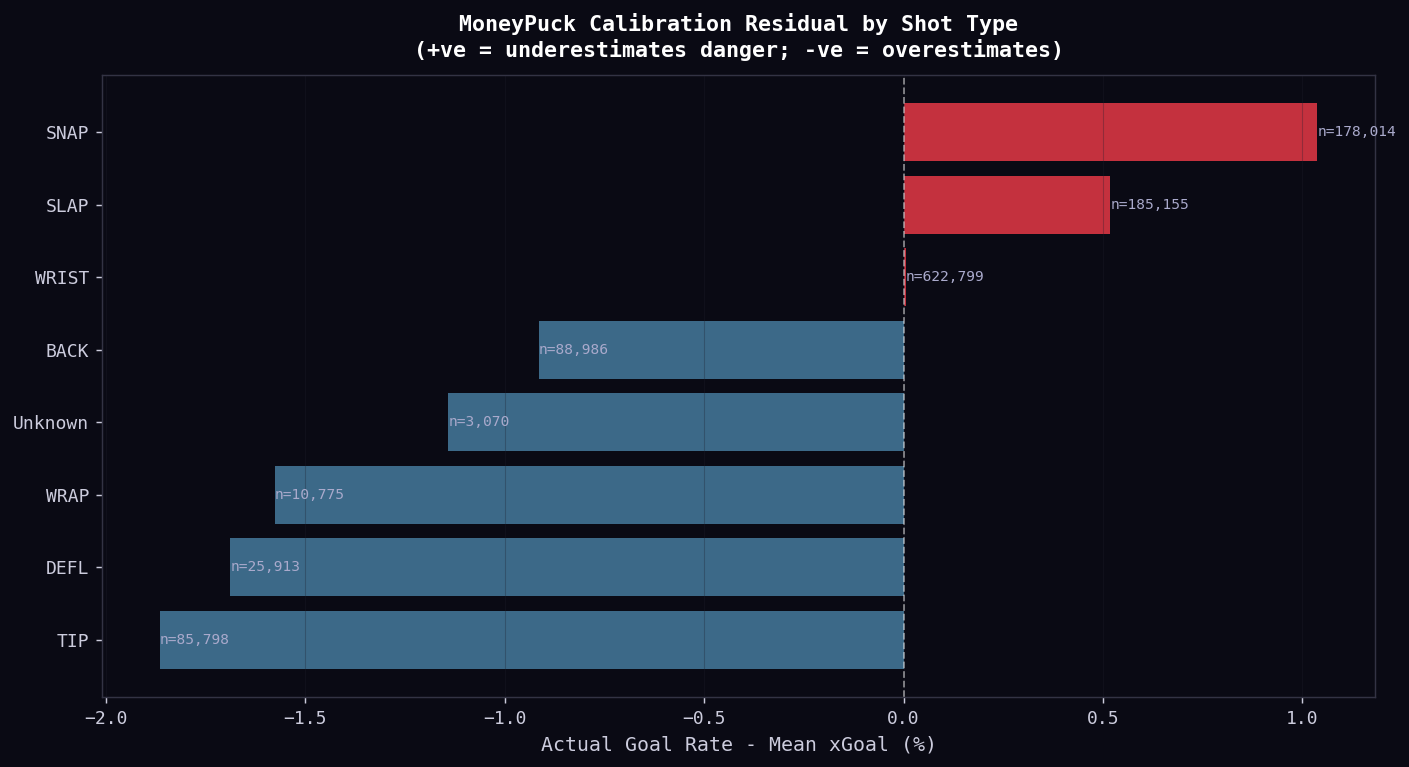

           shots  actual_rate  mean_xg  residual
shotType                                        
BACK       88986       0.0854   0.0946   -0.0092
DEFL       25913       0.0950   0.1119   -0.0169
SLAP      185155       0.0456   0.0404    0.0052
SNAP      178014       0.0793   0.0689    0.0104
TIP        85798       0.0956   0.1142   -0.0187
Unknown     3070       0.1648   0.1762   -0.0114
WRAP       10775       0.0544   0.0702   -0.0158
WRIST     622799       0.0659   0.0659    0.0000


In [21]:
# Calibration residual by shot type — full dataset
type_calib = oz.groupby('shotType').agg(
    shots=('goal', 'count'),
    actual_rate=('goal', 'mean'),
    mean_xg=('xGoal', 'mean')
).assign(residual=lambda d: d['actual_rate'] - d['mean_xg'])

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#0a0a14')
ax.set_facecolor('#0a0a14')

types     = type_calib.sort_values('residual').index
residuals = type_calib.loc[types, 'residual']
bar_colors = [GOAL_COLOR if r > 0 else NOGOAL_COLOR for r in residuals]

ax.barh(types, residuals * 100, color=bar_colors, alpha=0.85)
ax.axvline(0, color='white', lw=1, linestyle='--', alpha=0.5)
ax.set_xlabel('Actual Goal Rate - Mean xGoal (%)', fontsize=11)
ax.set_title('MoneyPuck Calibration Residual by Shot Type\n'
             '(+ve = underestimates danger; -ve = overestimates)',
             color='white', fontsize=12, fontweight='bold', pad=10)
ax.grid(axis='x', alpha=0.3)

for i, t in enumerate(types):
    ax.text(residuals[t] * 100 + 0.001, i,
            f'n={type_calib.loc[t, "shots"]:,}',
            va='center', fontsize=8, color='#aaaacc')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}07_calibration_by_type.png', bbox_inches='tight',
            facecolor='#0a0a14', dpi=150)
plt.show()

print(type_calib.round(4).to_string())

# Key finding:
# WRIST: +0.01pp residual — MoneyPuck is built around wrist shots
# SNAP:  underestimated +1.53pp — fast release, harder to track
# DEFL:  overestimated -3.67pp  } close-range shots that look dangerous
# TIP:   overestimated -3.08pp  } by location but goalies are already set

---
## 11. Jets vs. League

Checking whether Winnipeg generates different shot quality than the league — both in zone selection and in xG per shot within zones.

In [22]:
wpg = oz_reg[oz_reg['teamCode'] == 'WPG']

# Zone shooting % — Jets vs league
league_zone = oz_reg.groupby('zone')['goal'].mean().rename('league_pct')
wpg_zone    = wpg.groupby('zone')['goal'].mean().rename('wpg_pct')
zone_comp   = pd.concat([league_zone, wpg_zone], axis=1).dropna()
zone_comp['gap'] = zone_comp['wpg_pct'] - zone_comp['league_pct']

print('Zone shooting % (regulation):')
print((zone_comp * 100).round(2).to_string())

# Mean xG per shot
print('\nMean xG per shot:')
print(oz_reg.groupby(oz_reg['teamCode'] == 'WPG')['xGoal']
      .mean().rename({False: 'League', True: 'Jets'}).round(4))

# Mean xG per shot by zone
print('\nMean xG per shot by zone:')
league_xg = oz_reg.groupby('zone')['xGoal'].mean().rename('league_xg')
wpg_xg    = wpg.groupby('zone')['xGoal'].mean().rename('wpg_xg')
print(pd.concat([league_xg, wpg_xg], axis=1)
      .assign(gap=lambda d: d['wpg_xg'] - d['league_xg'])
      .round(4).to_string())



Zone shooting % (regulation):
           league_pct  wpg_pct   gap
zone                                
Circle           4.30     4.94  0.64
Corner           2.57     2.84  0.27
High Slot        8.77     8.48 -0.29
Point            2.60     2.64  0.04
Slot            11.83    12.36  0.52

Mean xG per shot:
teamCode
League    0.0690
Jets      0.0701
Name: xGoal, dtype: float64

Mean xG per shot by zone:
           league_xg  wpg_xg     gap
zone                                
Circle        0.0363  0.0382  0.0019
Corner        0.0247  0.0250  0.0003
High Slot     0.0808  0.0805 -0.0003
Point         0.0256  0.0264  0.0008
Slot          0.1246  0.1270  0.0024


Key finding:
- Jets are league-average in shot quality across all zones.
- Any over/underperformance vs expected goals is attributable to finishing skill or goaltending, not shot selection.

---
## 12. EDA Summary

In [23]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║               EDA SUMMARY — KEY FINDINGS                        ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. CLASS IMBALANCE                                              ║
║     7.0% goal rate (regulation). Use log-loss / Brier,          ║
║     NOT accuracy. Consider class_weight='balanced'.              ║
║                                                                  ║
║  2. GAME CONTEXT MATTERS                                         ║
║     3v3 OT: 13.8% goal rate vs 7.0% regulation (+6.8pp).        ║
║     MoneyPuck underestimates 3v3 OT by 4.4pp (9.4% xG           ║
║     vs 13.8% actual). Add game_context as a feature.            ║
║                                                                  ║
║  3. ZONE INEFFICIENCY                                            ║
║     Point = 29.6% of shots, 2.7% conversion.                    ║
║     Slot  = 38.2% of shots, 11.7% conversion (4x better).       ║
║     Teams fire a third of shots from the worst zone.            ║
║                                                                  ║
║  4. ANGLE IS WEAK ALONE — INTERACTION REQUIRED                   ║
║     0 degree shots at 27ft convert at 10.7% — clear lane,       ║
║     not the angle. Angle flat across 0-70 degrees.              ║
║     Add dist_sq + angle_x_dist interaction features.            ║
║                                                                  ║
║  5. MONEYPUCK MISCALIBRATION — CORE FINDING                      ║
║     Overestimates xG by 10-11pp in the 0.25-0.45 band.          ║
║     90% of affected shots are Slot (18.9% actual vs 31.5%).     ║
║     DEFL -17.9pp, TIP -15.1pp, WRAP -21pp.                      ║
║     WRIST perfectly calibrated (+0.01pp, n=182,382).            ║
║     SNAP underestimated +1.53pp — fast release, hard to track.  ║
║                                                                  ║
║  6. JETS FINDING                                                 ║
║     League-average shot quality in all zones (0.0728 vs         ║
║     0.0735 xG/shot). Over/underperformance driven by            ║
║     finishing or goaltending, not shot selection.               ║
║     Test this formally in notebook 05.                          ║
║                                                                  ║
║  7. FEATURES TO BUILD IN 02_feature_engineering.ipynb           ║
║     dist, angle, dist_sq, angle_x_dist, zone,                   ║
║     shot_type dummies, game_context, shooterLeftRight,          ║
║     shotRebound, shotRush, offWing, manpower situation          ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║               EDA SUMMARY — KEY FINDINGS                        ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. CLASS IMBALANCE                                              ║
║     7.0% goal rate (regulation). Use log-loss / Brier,          ║
║     NOT accuracy. Consider class_weight='balanced'.              ║
║                                                                  ║
║  2. GAME CONTEXT MATTERS                                         ║
║     3v3 OT: 13.8% goal rate vs 7.0% regulation (+6.8pp).        ║
║     MoneyPuck underestimates 3v3 OT by 4.4pp (9.4% xG           ║
║     vs 13.8% actual). Add game_context as a feature.            ║
║                                                                  ║
║  3. ZONE INEFFICIENCY                                            ║
║     Point = 29.6% of shots, 2.7% con

---
## 13. Save Handoff File

In [24]:
# Convert interval columns to strings for parquet compatibility
for col in ['dist_bin', 'angle_bin', 'xg_bin']:
    if col in oz.columns:
        oz[col] = oz[col].astype(str)

oz.to_parquet('../data/oz_clean.parquet', engine='fastparquet', index=False)

print(f'Saved oz_clean.parquet')
print(f'  Rows    : {len(oz):,}')
print(f'  Columns : {oz.shape[1]}')
print(f'  Figures : {FIGURES_DIR}')
print()


Saved oz_clean.parquet
  Rows    : 1,200,510
  Columns : 28
  Figures : ../outputs/figures/

Handoff to 02_feature_engineering.ipynb complete.
